# Prompt Chaining으로 더 똑똑한 답변 받기

## 1. API 연결

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

## 2. 상태 정의

In [4]:
from typing import Annotated, TypedDict
import operator

class ChainState(TypedDict):
    """Prompt Chaining을 위한 상태 정의"""
    user_input: str # 사용자 입력
    step1_output: str # 1단계: 초안 작성
    step2_output: str # 2단계: 구조화
    step3_output: str # 3단계: 최종 정제
    final_output: str # 최종 결과

print("상태 정의 완료!")
print("워크플로우: 초안 작성 → 구조화 → 최종 정제")

상태 정의 완료!
워크플로우: 초안 작성 → 구조화 → 최종 정제


## 3. Chaining Node 구현
1. draft_writer: 초안 작성
2. structurer: 내용 구조화
3. refiner: 최종 정제

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.7)

def draft_writer(state: ChainState) -> dict:
    """1단계: 초안 작성"""
    print("\nStep 1: 초안 작성 중 ... ")

    prompt = f"""다음 주제에 대해 자유롭게 아이디어를 브레인스토밍하고 초안을 작성해주세요.
형식이나 구조는 신경쓰지 말고, 모든 관련 내용을 포함해주세요.

주제: {state['user_input']}

초안: """

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"step1_output": response.content}


def structurer(state: ChainState) -> dict:
    """2단계: 내용 구조화"""
    print("\nStep 2: 구조화 중 ... ")

    prompt = f"""다음 초안을 잘 구조화된 형식으로 재구성해주세요.
- 명확한 섹션 구분
- 논리적 순서 배열
- 핵심 포인트 강조

초안:
{state['step1_output']}

구조화된 내용:"""

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"step2_output": response.content}


def refiner(state: ChainState) -> dict:
    """3단계: 최종 정제"""
    print("\nStep 3: 최종 정제 중 ... ")

    prompt = f"""다음 구조화된 내용을 명확하고 간결하게 정제해주세요.
- 불필요한 부분 제거
- 문장 다듬기
- 한국어로 작성

구조화된 내용:
{state['step2_output']}

최종 결과:"""
    
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"step3_output": response.content, "final_output": response.content}

print("체이닝 노드 구현 완료")

체이닝 노드 구현 완료


## 4. 그래프 구성
'''
START -> draft_writer -> structurer -> refiner -> END
'''

In [6]:
from langgraph.graph import StateGraph, START, END

# 그래프 생성
workflow = StateGraph[ChainState, None, ChainState, ChainState](ChainState)

# 노드 추가
workflow.add_node("draft_writer", draft_writer)
workflow.add_node("structurer", structurer)
workflow.add_node("refiner", refiner)

# 순차적 엣지 연결
workflow.add_edge(START, "draft_writer")
workflow.add_edge("draft_writer", "structurer")
workflow.add_edge("structurer", "refiner")
workflow. add_edge("refiner", END)

# 컴파일
chain_agent = workflow.compile()

print("Prompt Chaining 워크플로우 컴파일 완료!")

Prompt Chaining 워크플로우 컴파일 완료!


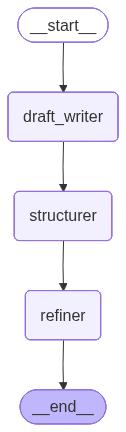

In [7]:
# 그래프 시각화
from IPython.display import Image, display
display(Image(chain_agent.get_graph().draw_mermaid_png()))

## 5. 실행

In [8]:
# 테스트: 블로그 포스트 작성

user_request = "AI 에이전트가 미래의 업무 방식을 어떻게 변화시킬지에 대한 블로그 포스트"

print(f"요청: {user_request}")
print("=" * 50)

result = chain_agent.invoke({"user_input": user_request})

print("\n최종 결과:")
print(result["final_output"])

요청: AI 에이전트가 미래의 업무 방식을 어떻게 변화시킬지에 대한 블로그 포스트

Step 1: 초안 작성 중 ... 

Step 2: 구조화 중 ... 

Step 3: 최종 정제 중 ... 

최종 결과:
# AI 에이전트가 미래 업무 방식을 변화시키는 방식

---

## 서론  
AI 기술의 급속한 발전은 업무 환경에 큰 변화를 가져오고 있습니다. 특히 AI 에이전트는 업무 방식을 혁신하며, 앞으로 생산성과 효율성을 크게 높일 것으로 기대됩니다. 본 글에서는 AI 에이전트가 미래 업무에 미칠 주요 변화를 살펴봅니다.

---

## 1. 자동화와 생산성 향상  
AI 에이전트는 이메일 분류, 일정 관리, 데이터 입력 등 반복적이고 단순한 업무를 대신 수행합니다. 이를 통해 직원들은 보다 창의적이고 전략적인 업무에 집중할 수 있습니다. 예를 들어, 콜센터에서 고객 문의를 자동으로 분류하고 응답하는 시스템이 고도화되고 있습니다.

---

## 2. 개인 맞춤형 업무 지원  
AI는 개인의 업무 습관과 선호도를 학습해 맞춤형 일정 관리와 우선순위 추천을 제공합니다. 집중력 향상을 위한 휴식 제안 등으로 업무 효율성과 직원 만족도를 높입니다.

---

## 3. 의사결정 지원과 데이터 분석  
AI는 방대한 데이터를 신속하게 분석해 유의미한 인사이트를 도출합니다. 경영진과 팀 리더는 시장 예측, 고객 행동 분석, 리스크 평가 등 AI의 분석 결과를 바탕으로 보다 현명한 의사결정을 할 수 있습니다.

---

## 4. 협업 방식의 변화  
AI 에이전트는 회의록 작성, 아이디어 정리, 프로젝트 진행 상황 추적을 자동화하며, 가상 비서 역할을 통해 부서 간, 글로벌 팀 간 원활한 커뮤니케이션을 지원합니다. 이를 통해 협업 효율성이 크게 향상됩니다.

---

## 5. 새로운 직무와 역할  
자동화가 확산되면서 인간은 고부가가치 업무에 집중하게 되고, AI 시스템 설계·운영, 윤리 감시 등 새로운 전문 직무가 생겨납니다. 미래 업무 환경은 인간과 AI가 상

In [13]:
# 각 단계별 결과 확인
print("단계별 결과 비교")
print("\n" + "=" * 60)

print("[Step 1: 초안]")
print(result["step1_output"][:100] +" ... ")
print("\n" + "=" * 60)

print("[Step 2: 구조화]")
print(result["step2_output"][:100] + " ... ")
print("\n" + "=" * 60)

print("[Step 3: 최종 정제]")
print(result["step3_output"][:100] + " ... ")

단계별 결과 비교

[Step 1: 초안]
AI 에이전트가 미래의 업무 방식을 어떻게 변화시킬지에 대한 생각을 정리해보겠습니다.

---

요즘 AI 기술이 빠르게 발전하면서, AI 에이전트가 우리 일상과 업무 환경에 미치 ... 

[Step 2: 구조화]
# AI 에이전트가 미래 업무 방식을 변화시키는 방식

---

## 서론  
최근 AI 기술의 급속한 발전은 우리 일상과 업무 환경에 지대한 영향을 미치고 있습니다. 특히 AI  ... 

[Step 3: 최종 정제]
# AI 에이전트가 미래 업무 방식을 변화시키는 방식

---

## 서론  
AI 기술의 급속한 발전은 업무 환경에 큰 변화를 가져오고 있습니다. 특히 AI 에이전트는 업무 방식 ... 
